In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set aesthetic style for the plots
sns.set_theme(style="white")

In [5]:
def scaled_dot_product_attention(query, key, value):
    """
    Implements the core Attention formula: softmax(QK^T / sqrt(d_k)) * V
    """
    d_k = query.shape[-1]
    
    # Calculate scores
    scores = np.matmul(query, key.T) / np.sqrt(d_k)
    
    # Softmax with numerical stability
    weights = np.exp(scores - np.max(scores))
    weights /= weights.sum(axis=-1, keepdims=True)
    
    # Final output
    output = np.matmul(weights, value)
    return output, weights

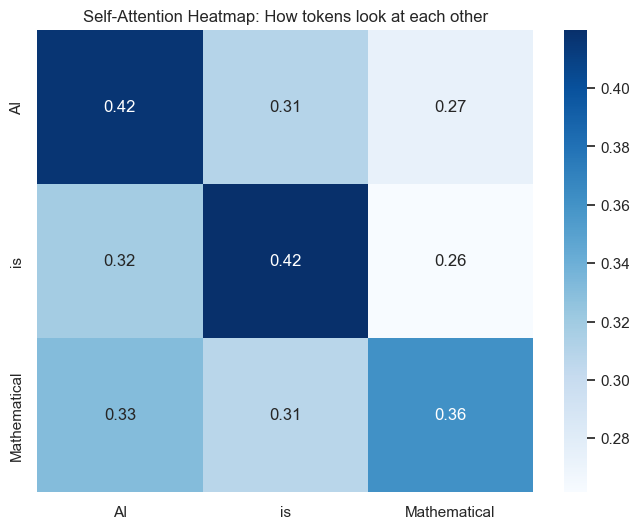

In [3]:
# Mock data: Sentence "AI is Mathematical"
tokens = ["AI", "is", "Mathematical"]
dim = 8  # Embedding dimension

# Initializing random vectors for Q, K, V
np.random.seed(101)
q = k = v = np.random.rand(3, dim)

# Run attention
context, weights = scaled_dot_product_attention(q, k, v)

# Create Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(weights, annot=True, xticklabels=tokens, yticklabels=tokens, cmap="Blues")
plt.title("Self-Attention Heatmap: How tokens look at each other")
plt.show()